# Métricas para Clasificación Binaria
## Dataset Statlog Australian Credit Approval

| Elemento | Descripción |
|---|---|
| Entradas (`X`) | Variables `A1` a `A14` (14 variables de entrada, problema multivariable) |
| Salida (`y`) | Variable `A15`: aprobación de crédito (1 = aprobado, 0 = rechazado) |
| ¿Qué estamos prediciendo? | Si una persona será aprobada o no para crédito |

### Significado de variables de entrada (`X`)

| Variable | Significado (guía práctica) |
|---|---|
| A1 | Perfil demográfico del solicitante (categoría) |
| A2 | Edad del solicitante |
| A3 | Nivel de deuda / compromiso financiero |
| A4 | Situación personal o de vivienda (categoría) |
| A5 | Tipo de cliente / historial administrativo (categoría) |
| A6 | Perfil laboral o educativo (categoría) |
| A7 | Antigüedad laboral / estabilidad en empleo |
| A8 | Estado de riesgo previo (categoría binaria) |
| A9 | Historial crediticio previo (cumplimiento/incumplimiento) |
| A10 | Intensidad de deuda o carga financiera actual |
| A11 | Indicador adicional de riesgo (binario) |
| A12 | Condición administrativa/legal del solicitante (categoría) |
| A13 | Capacidad de pago estimada |
| A14 | Ingreso o monto financiero reportado |

### Variable objetivo (`y`)

| Variable | Qué representa |
|---|---|
| A15 (`y`) | Resultado final del crédito: `1` aprobado, `0` rechazado |

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

## Carga y Preparación del Dataset

Cargamos `australian.dat`, separamos features y etiqueta, y hacemos split train/test.

In [27]:
data = pd.read_csv('australian.dat', sep=r'\s+', header=None)

X = data.iloc[:, :-1].values.astype(np.float64)
y = data.iloc[:, -1].values.astype(np.int64)

# Si la variable objetivo viene en {1,2}, la llevamos a {0,1}
if set(np.unique(y)) == {1, 2}:
    y = (y == 2).astype(np.int64)

np.random.seed(42)
idx = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Estandarización
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0) + 1e-8
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

print('Tamaño total      :', X.shape)
print('Tamaño train/test :', X_train.shape, X_test.shape)
print('Balance train     :', np.bincount(y_train))
print('Balance test      :', np.bincount(y_test))

Tamaño total      : (690, 14)
Tamaño train/test : (552, 14) (138, 14)
Balance train     : [311 241]
Balance test      : [72 66]


In [28]:
# Ver columnas del dataset
data.columns

# Si quieres nombres A1..A15 (más legibles)
data.columns = [f"A{i}" for i in range(1, data.shape[1] + 1)]
print(data.columns.tolist())

['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15']


## Entrenando un Clasificador Binario

Usamos una regresión logística implementada a mano (estilo perceptrón con sigmoid).

In [29]:
def bce(y, y_hat):
    y_hat = np.clip(y_hat, 1e-8, 1 - 1e-8)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class Perceptron:
    def __init__(self, size):
        self.w = np.random.normal(loc=0.0, scale=np.sqrt(2 / (size + 1)), size=(size,))
        self.ws = []
        self.activation = sigmoid
        self.loss = bce

    def __call__(self, w, x):
        return self.activation(np.dot(x, w))

    def fit(self, x, y, epochs, lr, verbose=True):
        x = np.c_[np.ones(len(x)), x]
        for epoch in range(1, epochs + 1):
            y_hat = self(self.w, x)
            l = self.loss(y, y_hat)
            dldh = (y_hat - y)
            dldw = np.dot(dldh, x) / len(x)
            self.w = self.w - lr * dldw
            self.ws.append(self.w.copy())
            if verbose and (epoch % 50 == 0 or epoch == 1):
                print(f'Época {epoch}/{epochs} Pérdida {l:.6f}')

In [30]:
np.random.seed(42)
perceptron = Perceptron(X_train.shape[1] + 1)
epochs, lr = 500, 0.05
perceptron.fit(X_train, y_train, epochs, lr, verbose=True)

Época 1/500 Pérdida 0.791723
Época 50/500 Pérdida 0.488214
Época 100/500 Pérdida 0.403293
Época 150/500 Pérdida 0.368875
Época 200/500 Pérdida 0.351556
Época 250/500 Pérdida 0.341442
Época 300/500 Pérdida 0.334917
Época 350/500 Pérdida 0.330445
Época 400/500 Pérdida 0.327258
Época 450/500 Pérdida 0.324920
Época 500/500 Pérdida 0.323166


## Métricas

A partir del modelo entrenado, evaluamos con varias métricas de clasificación binaria.

In [31]:
def evaluate(perceptron, x, t=0.5):
    w = perceptron.ws[-1]
    x = np.c_[np.ones(len(x)), x]
    y_prob = perceptron(w, x)
    return (y_prob > t).astype(np.int64)

def evaluate_proba(perceptron, x):
    w = perceptron.ws[-1]
    x = np.c_[np.ones(len(x)), x]
    return perceptron(w, x)

### Exactitud

In [32]:
y_pred_train = evaluate(perceptron, X_train)
y_pred_test = evaluate(perceptron, X_test)

print('Exactitud train:', accuracy_score(y_train, y_pred_train))
print('Exactitud test :', accuracy_score(y_test, y_pred_test))

Exactitud train: 0.8731884057971014
Exactitud test : 0.8695652173913043


In [33]:
# Línea base ingenua: predecir siempre la clase mayoritaria de train
majority_class = np.bincount(y_train).argmax()
y_naive = np.full_like(y_test, fill_value=majority_class)
print('Exactitud de línea base ingenua:', accuracy_score(y_test, y_naive))

Exactitud de línea base ingenua: 0.5217391304347826


### Matriz de Confusión

In [34]:
TP = np.sum((y_pred_test == 1) & (y_test == 1))
TN = np.sum((y_pred_test == 0) & (y_test == 0))
FP = np.sum((y_pred_test == 1) & (y_test == 0))
FN = np.sum((y_pred_test == 0) & (y_test == 1))

CM_manual = [[TN, FP], [FN, TP]]
CM_sklearn = confusion_matrix(y_test, y_pred_test)

print('Matriz manual  :', CM_manual)
print('Matriz sklearn :')
print(CM_sklearn)

Matriz manual  : [[np.int64(62), np.int64(10)], [np.int64(8), np.int64(58)]]
Matriz sklearn :
[[62 10]
 [ 8 58]]


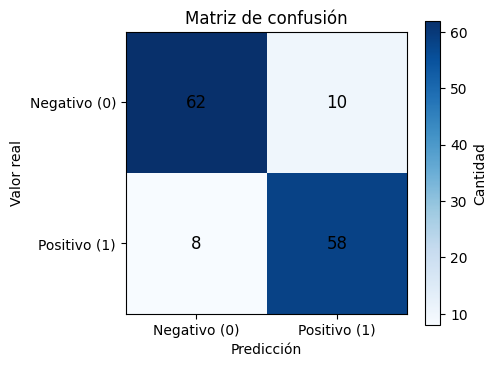

In [40]:
# Gráfica de la matriz de confusión
plt.figure(figsize=(5, 4))
plt.imshow(CM_sklearn, cmap='Blues')
plt.title('Matriz de confusión')
plt.colorbar(label='Cantidad')

etiquetas = ['Negativo (0)', 'Positivo (1)']
plt.xticks([0, 1], etiquetas)
plt.yticks([0, 1], etiquetas)
plt.xlabel('Predicción')
plt.ylabel('Valor real')

# Mostrar conteos dentro de cada celda
for i in range(CM_sklearn.shape[0]):
    for j in range(CM_sklearn.shape[1]):
        plt.text(j, i, str(CM_sklearn[i, j]), ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.show()

### Precisión y Recall

In [35]:
def precision(y_pred, y):
    TP = np.sum((y_pred == 1) & (y == 1))
    FP = np.sum((y_pred == 1) & (y == 0))
    return TP / (TP + FP + 1e-8)

def recall(y_pred, y):
    TP = np.sum((y_pred == 1) & (y == 1))
    FN = np.sum((y_pred == 0) & (y == 1))
    return TP / (TP + FN + 1e-8)

print('Precisión manual:', precision(y_pred_test, y_test))
print('Recall manual   :', recall(y_pred_test, y_test))
print('Precisión sklearn:', precision_score(y_test, y_pred_test))
print('Recall sklearn   :', recall_score(y_test, y_pred_test))

Precisión manual: 0.8529411763451558
Recall manual   : 0.8787878786547292
Precisión sklearn: 0.8529411764705882
Recall sklearn   : 0.8787878787878788


In [36]:
for t in np.linspace(0.1, 0.9, 9):
    y_pred_t = evaluate(perceptron, X_test, t)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    print(f'Umbral: {t:.2f} Precisión: {p:.4f} Recall: {r:.4f}')

Umbral: 0.10 Precisión: 0.6809 Recall: 0.9697
Umbral: 0.20 Precisión: 0.7722 Recall: 0.9242
Umbral: 0.30 Precisión: 0.7792 Recall: 0.9091
Umbral: 0.40 Precisión: 0.8219 Recall: 0.9091
Umbral: 0.50 Precisión: 0.8529 Recall: 0.8788
Umbral: 0.60 Precisión: 0.9298 Recall: 0.8030
Umbral: 0.70 Precisión: 0.9259 Recall: 0.7576
Umbral: 0.80 Precisión: 0.9333 Recall: 0.6364
Umbral: 0.90 Precisión: 1.0000 Recall: 0.3636


### Puntaje F1

In [37]:
p = precision_score(y_test, y_pred_test)
r = recall_score(y_test, y_pred_test)
f1_manual = 2 * (p * r) / (p + r + 1e-8)

print('F1 manual :', f1_manual)
print('F1 sklearn:', f1_score(y_test, y_pred_test))

F1 manual : 0.8656716367921586
F1 sklearn: 0.8656716417910447


### Curva ROC y Área Bajo la Curva (AUC)

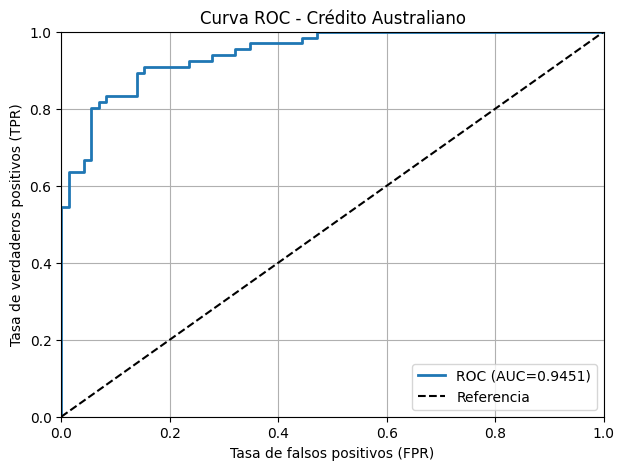

Área bajo la curva ROC (AUC): 0.9450757575757576


In [38]:
y_score = evaluate_proba(perceptron, X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC={auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Referencia')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Crédito Australiano')
plt.grid(True)
plt.legend()
plt.show()

print('Área bajo la curva ROC (AUC):', auc)